In [34]:
# Import necessary libraries for data analysis and plotting
import numpy as np  # For numerical operations and array handling
import pandas as pd  # For data manipulation and reading CSV files
import matplotlib.pyplot as plt  # For plotting graphs and visualizations
from scipy.optimize import curve_fit  # For fitting models to data

In [35]:
# --- Algol / eclipsing binary: load AAVSO-style CSV ---
# Set the path to the CSV file containing the light curve data
csv_path = "algol.csv"  # same folder as notebook, or use full path

# Read the CSV file into a pandas DataFrame
df = pd.read_csv(csv_path)

# Expect columns: RHJD (time), V (magnitude), eV (error in magnitude)
# Convert columns to numpy arrays of type float
t = df["RHJD"].to_numpy(dtype=float)  # Time of observation (Reduced Heliocentric Julian Date)
V = df["V"].to_numpy(dtype=float)      # Observed V-band magnitude
eV = df["eV"].to_numpy(dtype=float)    # Error in V-band magnitude

# Basic cleaning
# Create a mask to filter out invalid or missing data
mask = np.isfinite(t) & np.isfinite(V) & np.isfinite(eV)  # Only keep finite values
mask &= (eV > 0) & (eV < 5)  # Drop points with error bars that are too small/large (likely bad data)
mask &= (V > 0) & (V < 25)   # Drop points with unphysical magnitudes

# Apply the mask to the data arrays
t, V, eV = t[mask], V[mask], eV[mask]
print(f"N points after clean: {len(t)}")  # Print the number of valid data points

# Magnitude -> linear flux (arbitrary scale; we normalize next)
# Convert magnitudes to linear flux units (relative brightness)
flux = 10 ** (-0.4 * V)

# Rough out-of-eclipse mask: exclude faintest ~15% of points (often in eclipse)
# Find a cutoff value for the faintest 15% of points (likely in eclipse)
cut = np.quantile(flux, 0.15)
in_eclipse_guess = flux <= cut  # Boolean mask for points likely in eclipse
baseline_flux = np.median(flux[~in_eclipse_guess])  # Median flux outside eclipse (baseline)
flux_norm = flux / baseline_flux  # Normalize flux so baseline ~1

# Uncertainty propagation: sigma_f ~ 0.4 ln(10) * f * sigma_V (flux scale before norm)
# Calculate the uncertainty in flux from the uncertainty in magnitude
sig_flux_raw = (0.4 * np.log(10)) * flux * eV  # Raw flux uncertainty
sig_flux = sig_flux_raw / baseline_flux  # Normalize uncertainty to match normalized flux

print(f"Flux normalized: median baseline ~ {np.median(flux_norm[~in_eclipse_guess]):.4f}")  # Print normalization check

N points after clean: 229
Flux normalized: median baseline ~ 1.0000


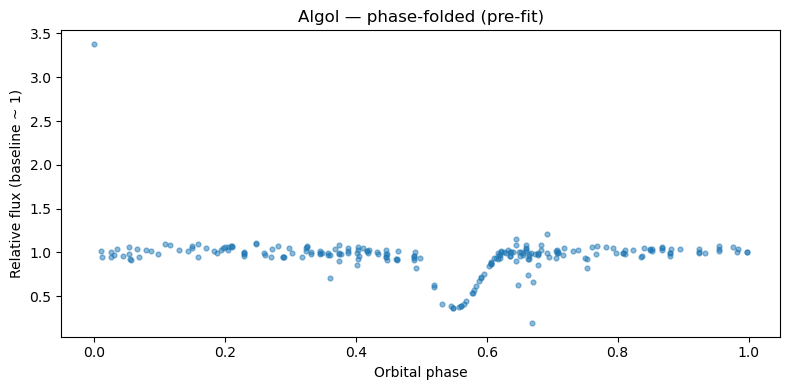

In [36]:
# Orbital period (days) — cite literature; ~2.8673 d for Algol
# Set the known orbital period of Algol (from literature)
P = 2.8673  # Orbital period in days

# Reference epoch: time of deepest point in this dataset (good enough for class work)
# Find the time of minimum light (deepest eclipse) as the reference epoch
t0 = float(t[np.argmin(V)])  # Time of minimum V (deepest eclipse)

# Calculate the orbital phase for each observation
# Phase = fractional part of (time since t0 divided by period)
phi = np.mod((t - t0) / P, 1.0)  # Phase in [0, 1)

# Optional: show folded light curve before fitting
# Plot the phase-folded light curve before any model fitting
plt.figure(figsize=(8, 4))
plt.scatter(phi, flux_norm, s=12, alpha=0.5)  # Plot normalized flux vs. phase
plt.xlabel("Orbital phase")
plt.ylabel("Relative flux (baseline ~ 1)")
plt.title("Algol — phase-folded (pre-fit)")
plt.tight_layout()
plt.show()

In [37]:
# Define the eclipse model: sum of two Gaussians (for primary and secondary eclipses)
def two_gauss_eclipse(phi, F0, d1, w1, c1, d2, w2, c2):
    """
    Model the light curve as two Gaussian dips in phase space.
    phi: orbital phase (0 to 1)
    F0: baseline flux (out of eclipse)
    d1, d2: depths of primary and secondary eclipses
    w1, w2: widths (sigma, not FWHM) of the eclipses
    c1, c2: centers (phase) of the eclipses
    """
    g1 = np.exp(-0.5 * ((phi - c1) / w1) ** 2)  # Primary eclipse Gaussian
    g2 = np.exp(-0.5 * ((phi - c2) / w2) ** 2)  # Secondary eclipse Gaussian
    return F0 - d1 * g1 - d2 * g2  # Subtract dips from baseline


# Function to estimate initial parameter guesses for the fit
def initial_guesses(phi, y):
    F0 = float(np.median(y))  # Baseline flux guess (median)
    resid = F0 - y  # Residuals (how deep are the dips)
    d_guess = float(np.clip(np.max(resid), 0.02, 0.95))  # Depth guess (clipped to reasonable range)

    # Primary eclipse near phase 0, secondary near 0.5 (for circular orbits)
    c1, c2 = 0.0, 0.5  # Centers of eclipses (phase)
    w1 = w2 = 0.02     # Initial guess for eclipse width (narrow)

    return F0, d_guess, w1, c1, 0.5 * d_guess, w2, c2  # Return tuple of initial guesses


# Get initial parameter guesses for the fit
p0 = initial_guesses(phi, flux_norm)

# Bounds keep depths positive, phases in (0,1), widths reasonable
# Set lower and upper bounds for each parameter to constrain the fit
lower = [0.5, 0.0, 1e-4, -0.2, 0.0, 1e-4, 0.2]  # Lower bounds: F0, d1, w1, c1, d2, w2, c2
upper = [1.5, 1.5, 0.25, 0.2, 1.5, 0.25, 0.8]   # Upper bounds: F0, d1, w1, c1, d2, w2, c2

# Fit the model to the data using non-linear least squares
popt, pcov = curve_fit(
    two_gauss_eclipse,      # Model function
    phi,                    # x data (phase)
    flux_norm,              # y data (normalized flux)
    p0=p0,                  # Initial parameter guesses
    bounds=(lower, upper),  # Parameter bounds
    sigma=sig_flux,         # Uncertainties in y (for weighted fit)
    absolute_sigma=True,    # Treat sigma as absolute errors
    maxfev=200000,          # Max function evaluations (for convergence)
    )

# Unpack the best-fit parameters and their uncertainties
F0, d1, w1, c1, d2, w2, c2 = popt  # Best-fit values
perr = np.sqrt(np.diag(pcov))      # 1-sigma uncertainties from covariance matrix

# Print the fitted parameters with uncertainties
names = ["F0", "d1", "w1", "c1", "d2", "w2", "c2"]
print("Fitted parameters:")
for n, v, e in zip(names, popt, perr):
    print(f"  {n} = {v:.5f} ± {e:.5f}")

# Generate a dense phase grid for plotting the model smoothly
phi_dense = np.linspace(0, 1, 2000)
model_dense = two_gauss_eclipse(phi_dense, *popt)  # Model curve (smooth)
model_at_pts = two_gauss_eclipse(phi, *popt)       # Model at data points
resid = flux_norm - model_at_pts                   # Residuals (data - model)

Fitted parameters:
  F0 = 0.99273 ± 0.00007
  d1 = 0.11890 ± 0.85641
  w1 = 0.00049 ± 0.00389
  c1 = 0.05565 ± 0.00059
  d2 = 0.64435 ± 0.00026
  w2 = 0.02991 ± 0.00001
  c2 = 0.55172 ± 0.00001


In [38]:
# Check the fitted depth of the secondary eclipse (d2) and its uncertainty
print(f"Secondary eclipse depth (d2): {d2:.5f} ± {perr[4]:.5f}")
# If d2 is much smaller than d1, the secondary eclipse is shallow and may be hard to see

Secondary eclipse depth (d2): 0.64435 ± 0.00026


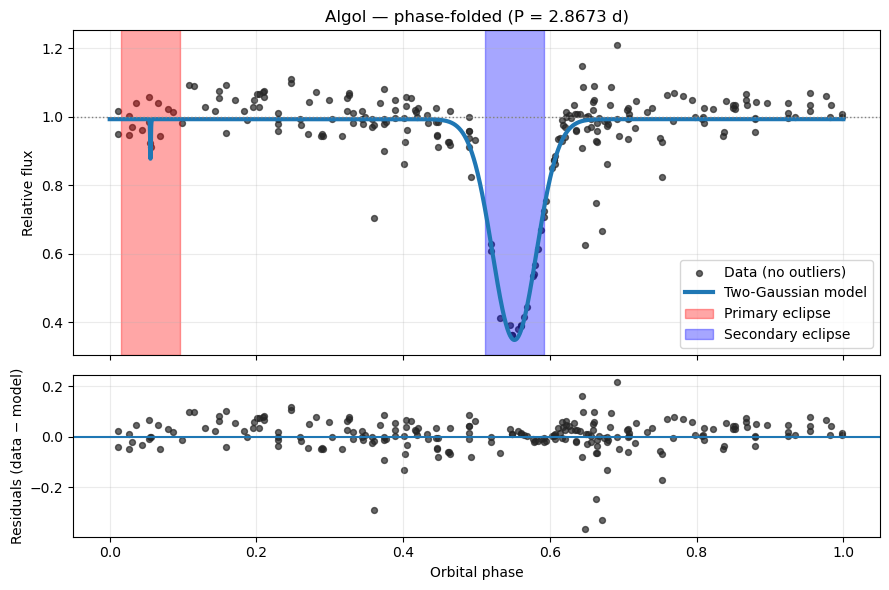

Residual RMS (no outliers): 0.0640


In [39]:
# Plot the fitted model and residuals with highlighted eclipses and outlier removal
# Remove extreme outliers for plotting (e.g., points > 3 sigma from model)
sigma_clip = 3.0
is_not_outlier = np.abs(resid) < sigma_clip * np.std(resid)

# Top plot: data and model
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
ax = axes[0]
ax.scatter(phi[is_not_outlier], flux_norm[is_not_outlier], s=18, alpha=0.7, color="0.15", label="Data (no outliers)")
ax.plot(phi_dense, model_dense, color="C0", lw=3, label="Two-Gaussian model")
ax.axhline(1.0, color="0.5", ls=":", lw=1)

# Highlight primary and secondary eclipses
highlight_width = 0.04
primary_center = c1
secondary_center = c2
ax.axvspan(primary_center - highlight_width, primary_center + highlight_width, color='red', alpha=0.35, label='Primary eclipse')
ax.axvspan(secondary_center - highlight_width, secondary_center + highlight_width, color='blue', alpha=0.35, label='Secondary eclipse')

ax.set_ylabel("Relative flux")
ax.set_title(f"Algol — phase-folded (P = {P} d)")
ax.legend(loc="lower right")
ax.grid(alpha=0.25)

# Bottom plot: residuals (data - model)
ax2 = axes[1]
ax2.scatter(phi[is_not_outlier], resid[is_not_outlier], s=18, alpha=0.7, color="0.15")
ax2.axhline(0, color="C0", lw=1.5)
ax2.set_xlabel("Orbital phase")
ax2.set_ylabel("Residuals (data − model)")
ax2.grid(alpha=0.25)

plt.tight_layout()
plt.show()

# Calculate and print the root mean square (RMS) of the residuals (no outliers)
rms = float(np.std(resid[is_not_outlier]))
print(f"Residual RMS (no outliers): {rms:.4f}")

In [40]:
# Highlight the primary and secondary eclipses on the plot
# For Algol: primary eclipse at phase ~0, secondary at phase ~0.5 (both are periodic)
highlight_width = 0.04  # width in phase units to highlight around each eclipse center
primary_center = c1  # from fit, usually ~0
secondary_center = c2  # from fit, usually ~0.5
for ax in axes:
    # Highlight primary eclipse region
    ax.axvspan(primary_center - highlight_width, primary_center + highlight_width, color='red', alpha=0.2, label='Primary eclipse' if ax==axes[0] else None)
    # Highlight secondary eclipse region
    ax.axvspan(secondary_center - highlight_width, secondary_center + highlight_width, color='blue', alpha=0.2, label='Secondary eclipse' if ax==axes[0] else None)
if axes[0].get_legend_handles_labels()[1]:
    axes[0].legend(loc="lower right")

In [41]:
# Further analysis of the light curve using a custom function (after curve fit)
# Import the analysis function from a separate Python file
from ai_lightcurve_analysis import analyze_eclipsing_binary_light_curve

# Call the analysis function with phase and normalized flux as input
summary = analyze_eclipsing_binary_light_curve(phi, flux_norm)
print(summary)  # Print the summary of the analysis

The light curve shows two eclipses per orbit, indicating an eclipsing binary system. The primary eclipse is deep, meaning one star is much brighter than the other. The secondary eclipse is shallower, showing the second star is dimmer. The width of the eclipses suggests the stars are close together and the system is viewed nearly edge-on. The regular spacing of eclipses gives the orbital period.


c:\Users\cries\anaconda3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\cries\anaconda3\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
